# Generative Adversarial Networks as Synthetic Texture Tools

## Objective Overview - Entering the Narrative

<h4><b><i>:: Objective Summary ::</i></b>
<br>
<br>
Exploration of the use of GANs as synthetic texture generation and modification tools as seen in a targetted DCC (Digital Content Creation) pipeline - namely, Autodesk Maya to Unreal Engine 5. The goal is to create synthetic textures that can be used similarly to baked PBR textures, though wtih more control in the generation process<a href="https://ieeexplore-ieee-org.uvu.idm.oclc.org/document/9755570">[2]</a>, similarly to procedural texture approaches.
<br>
Aside from all else, StyleGAN, SGAN, PSGAN, and ERGAN can be used and then compared in analysis terms, and their result against non-neural texture synthesis (quilting).
<br><br>
<b><i>:: Generative Adversarial Network ::</i></b>
<br><br>
GANs are one of several Deep Learning models proposed as content generation tools today, and have only gained traction since their initial debut from Goodfellow in 2015<a id='link_goodfellow'>[1]</a>. The model pits two Machine Learning models against one another, attempting to train one to fool the other. The components and process are defined as follows::
<br><br>
    <li>A <b><i>Generator</i></b> which synthesizes an similar image to an original from a dataset</li>
    <li>A <b><i>Discriminator</i></b> which checks this image against known generated and real image files</li>

Once the comparison ruling is made by the Discriminator, the Generator compares the result output and adjusts for new image generation. This comparison process continues until the Discriminator can no longer distinguish a generated image from an organic one. There are many differing types of GANs<a href="https://ieeexplore-ieee-org.uvu.idm.oclc.org/document/9755570">[2]<a href="https://www.sciencedirect.com/science/article/pii/S277267112300181X">[5]</a>, although this project aims to take the most state-of-the-art of them in PSGAN[4] vs StyleGan3[#?], and put it against texture synthesis via quilting[6] to showcase what Neural Texture Synthesis is capable of today, alongside building a simple GAN myself in order to understand the technology.
<br><br>
This project explores the application of GANs in the following areas::
<i>
<li>Texture Synthesis</li>
<li>Texture Upscaling</li>
<li>Texture Style Transfer</li>
<li>Texture Proceduralism</li>
</i>
<br>
*A brief review and definition of these technologies can optionally be found in the review section below.</h4>

## Texture Features - Reviewing Approaches

<h4>
<b><i>:: What are Textures, and Why Are They Important? ::</i></b>
<br><br>
Textures are 1D, 2D, or even 3D chunks of image and other data that are fed into the graphics pipeline in order to get information onto the graphics card. Upon reaching the graphics card, textures are assigned texel units to maintain them, and pass their information to small graphics-card-run programs known as <b><i>Shaders</i></b>. 
<br><li>Shaders are the underlying programs for all materials in 3D rendering applications and VFX of any kind, and are the end goal of utilizing various texture methods to create desired materials in 3D rendering.
</li>
<br>
<b><i>:: How are Textures Created? ::</i></b>
<br><br>
There are many approaches to texture generation that vary in trade-offs from complexity of approach to computational difficulty, with some that are quite time consuming or memory intensive. 
<li><b><i>Physically Based Rendering</i></b> packages using an initial texture and accompanying texture maps to define roughness and other virtual geometry, which has been quite popular throughout the decade, but suffers as texture resolution expands, throttling GPU resources.</li>
<li><b><i>Procedural Textures</i></b> are a fairly recent approach on the scene, using mathematical formulas and programs - often node-based "shader graphs" to create textures within a given application. Although the benefits of procedural textures are vast, especially in versatility and customization, they lack the ability to move from program to program, needing to "bake" a texture into an image file similar to Physically Based Rendering (PBR) textures to move application.</li>
<li><b><i>Deep Learning Synthetic Textures</i></b> have gained popularity in research environments due to recent advancements in AI and Machine Learning[3], but have yet to reach major production utilization. Though they currently exist primarily in the field of study of Texture Synthesis, <i>I hope to explore GANs to create toggles similar to Procedural Texture's versatility, while being able to bake these textures out onto materials or meshes as in PBR, possibly creating a content generation tool in the process.</i>
<br><br>
<b><i>:: What Texture Technologies are Explored in this Project? ::</i></b>
<br><br>
<b><i>Texture Synthesis</i></b> - the process of generating novel textures from samples of existing textures and imagery, typically using 2D images with three RGB color channels<a href="https://ieeexplore-ieee-org.uvu.idm.oclc.org/document/9755570">[2]</a>.
<br>
<b><i>Texture Upscaling</i></b> - similar to image upscaling in that we grow from one resolution to another, then replace original texture images with upscaled ones.
<br>
<b><i>Texture Style Transfer</i></b> - blending a base image with a target texture, in order to overlay the original with the style of the target
<br>
<b><i>Texture Proceduralism</i></b> - mathematical or algorithmically generated textures within a given Digital Content Creation tool.
</h4>

## Dataset Exploration - A Familiar Catalogue

<h4>
<b><i>:: Personal Image Library ::</i></b>
<br><br>
Borrowed from the midterm project is a repository of collected images. These images have been pre-processed via image processing means to be consistent sizes.
</h4>

<h4>
<b><i>:: Imports and Textureset Loading ::</i></b>
</h4>

In [9]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from Models.gan_multimodal import *
from Models.discriminator_multimodal import *
from Models.generator_multimodal import *
from Utility.image_processing import AssetParser, TextureDataset

# Target Pixel Size
pixel_size = 256
texture_batch_size = 64

# Define transformations (for augmentation and normalization)
texture_transform = transforms.Compose([
    transforms.Resize((pixel_size, pixel_size)),  # Resize the image to 256x256
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),  # Random rotation between -30 and 30 degrees
    transforms.ToTensor(),          # Convert images to tensor for PyTorch
])

# Build Textures array from zip
asset_parser = AssetParser()
brick_textures, brick_texture_path = asset_parser.load_textures_from_zip("../Image/textures/brick.zip")

<h4>
<b><i>:: Visual Exploration of Textures ::</i></b>
</h4>

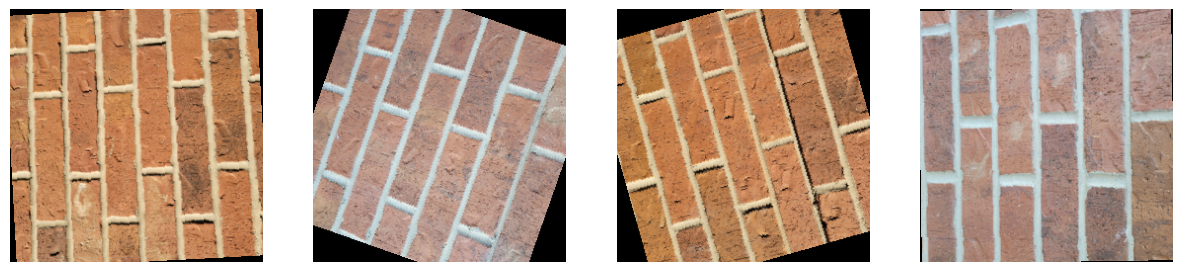

In [10]:
# Clean texture path later
# asset_parser.remove_excess_directory(brick_texture_path)

# Create textureset for batch processing
textureset = TextureDataset(brick_textures, texture_transform)
texture_dataloader = DataLoader(textureset, batch_size=texture_batch_size, shuffle=True)

# Display of textures
textureset.display_textures(texture_dataloader, num_images=4)

<h4>
<b><i>:: Splitting the Texture Data ::</i></b>
</h4>

In [11]:
train_size = int(0.8 * len(textureset))
val_size = len(textureset) - train_size
train_dataset, val_dataset = random_split(textureset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=texture_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=texture_batch_size)

<h4>
<b><i>:: Initialize Multi-Modal GAN ::</i></b>
</h4>

In [12]:
# Hyperparameters for Multimodal GAN
latent_dim = 100       
lr = 0.0002           
epochs = 50

# Get our multimodal models
# generator = MultiModalGenerator(mode='SYNTHESIS')
# discriminator = MultiModalDiscriminator(mode='SYNTHESIS')
generator = MultiModalGenerator(mode='SYNTHESIS', pixel_size=pixel_size).to('cuda')
discriminator = MultiModalDiscriminator(mode='SYNTHESIS').to('cuda')

# Multimodal GAN - TEXTURE SYNTHESIS
texture_gan = MultiModalGAN(
    generator=generator,
    discriminator=discriminator,
    mode="SYNTHESIS",
    latent_dim=100,
    lr=0.0002,
    pixel_size=pixel_size
)

<h4>
<b><i>:: Train the GAN - Texuture Synthesis ::</i></b>
</h4>

In [13]:
# Define loss as BCELoss
criterion = nn.BCELoss()

# Training Loop
epochs = 50
for epoch in range(epochs):
    for real_images in texture_dataloader:
        real_images = real_images.to('cuda')

        print("Image Size:: ",real_images.size())
        if real_images.shape[2:] != (pixel_size, pixel_size):
            real_images = F.interpolate(real_images, size=(pixel_size, pixel_size))
        print("Image Size:: ",real_images.size())
        
        # Generate fake images
        batch_size = real_images.size(0)
        noise = torch.randn(batch_size, 100, 1, 1).to('cuda')
        fake_images = texture_gan.generator(noise)

        # Perform a training step
        loss_g, loss_d = texture_gan.train_step(real_images)  # `train_step` already updates the optimizer

        # Print losses for each batch
        print(f"Epoch [{epoch + 1}/{epochs}], Loss G: {loss_g:.4f}, Loss D: {loss_d:.4f}")

print("Training Complete!")

# Generating images after training
batch_size = 16
generated_textures = texture_gan.generate(batch_size)
generated_textures = (generated_textures + 1) / 2 

# Display the images
grid = vutils.make_grid(generated_textures, nrow=4, padding=2, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

Image Size::  torch.Size([4, 3, 256, 256])
Image Size::  torch.Size([4, 3, 256, 256])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x131072 and 8192x1)

## Conclusions

<h4>
<b>:: On Neural Texture Synthesis as a Tool ::</b>
<br>
Even not having finished my work on this project, this approach is not yet commercially ready. Neural Texture Synthesis takes an enormous amount of compute[2], all to attempt to save time for the 3D artist, but even with today's greatest hardwares it does not seem to come close to what a proficient procedural texture artist could do in the same time - at which point they would be able to modify it for variations as well.
I could see style transfer and upscaling being effective tools at this time, however. 
</h4>

## Resources and References

[1] Goodfellow, Generative Adversarial Networks, 2015.
<br>
<a href="https://ieeexplore-ieee-org.uvu.idm.oclc.org/document/9755570">[2]</a> Vladimir V. Gurenko et al, Analysis of Texture Synthesis Algorithms in Computer Graphics, 2022.
<br>
<a href="">[3]</a> N. Jetchev, U. Bergmann and R. Vollgraf, Texture Synthesis with Spatial Generative Adversarial Networks, 2016.
<br>
<a href="">[4]</a> N. Jetchev, U. Bergmann and R. Vollgraf, Learning Texture Manifolds with the Periodic Spatial GAN, 2017.
<br>
<a href="https://www.sciencedirect.com/science/article/pii/S277267112300181X">[5]</a> Texture Representation via Analysis and Synthesis with Generative Adversarial Networks, 2023.
<br>
<a href="">[6]</a> A. A. Efros and W.T. Freeman, Image Quilting for Texture Synthesis and Transfer, 2001.
<br>
<a href="https://arxiv.org/pdf/2010.04548">[7]</a> Julian Togelius et al., Deep Learning for Procedural Content Generation

Essentially, there is no solution for any given texture yet - this is the edge of the horizon for texture synthesis, and research is ongoing, with PSGAN currently leading.